# 11. 꽃 CNN 결과 분석과 오답 확인

10장에서는 꽃 이미지를 분류하는 CNN 모델을 만들고 저장했습니다.

이번 장에서는 모델의 정확도만 보는 것이 아니라, 어떤 꽃을 잘 맞히고 어떤 꽃을 헷갈리는지 확인합니다.

핵심 질문은 다음과 같습니다.

```text
전체 정확도는 어느 정도인가?
어떤 클래스의 성능이 낮은가?
어떤 꽃끼리 자주 헷갈리는가?
모델이 틀린 이미지는 실제로 어떤 모습인가?
```

## 1. 라이브러리 불러오기

이번 장에서는 모델 예측 결과를 표와 그림으로 분석합니다.

`sklearn.metrics`에서는 Confusion Matrix와 분류 리포트를 만들 수 있습니다.

In [1]:
# pathlib.Path는 파일과 폴더 경로를 다루기 위한 도구입니다.
from pathlib import Path

# numpy는 숫자 배열을 다루는 대표 라이브러리입니다.
import numpy as np

# pandas는 표 형태의 데이터를 다룰 때 사용합니다.
import pandas as pd

# matplotlib.pyplot은 그래프와 이미지를 그릴 때 사용합니다.
import matplotlib.pyplot as plt

# tensorflow는 Keras 모델의 예측값에 softmax를 적용할 때 사용합니다.
import tensorflow as tf

# load_model은 저장된 Keras 모델을 다시 불러오는 함수입니다.
from keras.models import load_model

# confusion_matrix는 정답과 예측이 어떻게 엇갈렸는지 표로 만들어 줍니다.
# classification_report는 precision, recall, f1-score를 클래스별로 정리해 줍니다.
from sklearn.metrics import confusion_matrix, classification_report

## 2. 경로와 기본 설정

10장과 같은 꽃 이미지 폴더를 사용합니다.

또한 10장에서 저장한 모델 파일을 불러옵니다.

In [2]:
# 꽃 이미지 데이터가 들어 있는 폴더입니다.
DATA_DIR = Path(r"C:\work\deepLearning\flower_dataset\flower_photos")

# 10장에서 저장한 모델 파일 경로입니다.
MODEL_PATH = Path(r"C:\work\deepLearning\model\flower_cnn_mini_project.keras")

# 10장과 같은 이미지 크기와 배치 크기를 사용합니다.
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

print("데이터 폴더 존재 여부:", DATA_DIR.exists())
print("모델 파일 존재 여부:", MODEL_PATH.exists())

데이터 폴더 존재 여부: True
모델 파일 존재 여부: True


## 3. 검증 데이터셋 다시 만들기

모델을 평가하려면 10장과 같은 방식으로 검증 데이터셋을 다시 만들어야 합니다.

중요한 점은 `validation_split`, `subset`, `seed`, `image_size`를 10장과 맞추는 것입니다.

그래야 같은 기준의 검증 데이터를 사용하게 됩니다.

In [3]:
# validation_split=0.2는 전체 데이터 중 20%를 검증용으로 쓰겠다는 뜻입니다.
# subset="validation"은 그중 검증용 부분만 가져오겠다는 뜻입니다.
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True  # 분석할 때는 순서를 고정하는 것이 결과 확인에 좋습니다.
)

# Keras가 폴더 이름에서 읽어 온 클래스 이름입니다.
class_names = val_ds.class_names
num_classes = len(class_names)

print("클래스 이름:", class_names)
print("클래스 개수:", num_classes)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.
클래스 이름: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
클래스 개수: 5


## 4. 저장된 모델 불러오기

`load_model()`은 저장된 Keras 모델 파일을 다시 메모리로 불러옵니다.

모델을 저장해 두면 노트북을 껐다 켜도 다시 학습하지 않고 예측에 사용할 수 있습니다.

In [4]:
# load_model()은 모델 구조와 학습된 가중치를 함께 불러옵니다.
# 만약 MODEL_PATH가 없다면 10장 노트북을 먼저 실행해서 모델을 저장해야 합니다.
model = load_model(MODEL_PATH)

# summary()는 불러온 모델의 구조를 확인합니다.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,276,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,903,473 (37.78 MB)

 Trainable params: 3,301,157 (12.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,602,316 (25.19 MB)

## 5. 검증 데이터 전체 예측하기

Confusion Matrix를 만들려면 검증 데이터 전체에 대해 정답과 예측을 모아야 합니다.

이번 셀에서는 다음 세 가지를 리스트에 저장합니다.

```text
이미지
실제 정답
모델 예측
```

In [5]:
all_images = []
all_true_labels = []
all_pred_labels = []
all_confidences = []

# val_ds는 여러 배치로 나뉘어 있습니다.
# for문으로 배치를 하나씩 꺼내 전체 검증 데이터를 예측합니다.
for images, labels in val_ds:
    # predict()는 모델이 각 이미지에 대해 클래스별 점수를 출력합니다.
    logits = model.predict(images, verbose=0)
    
    # softmax는 클래스별 점수를 확률처럼 해석할 수 있는 값으로 바꿉니다.
    probabilities = tf.nn.softmax(logits, axis=1).numpy()
    
    # argmax는 가장 큰 확률을 가진 클래스 번호를 고릅니다.
    pred_labels = np.argmax(probabilities, axis=1)
    
    # max는 모델이 고른 클래스의 확률, 즉 예측 확신도를 가져옵니다.
    confidences = np.max(probabilities, axis=1)
    
    # append 대신 extend를 사용하면 배치 안의 여러 항목을 한꺼번에 리스트에 추가할 수 있습니다.
    all_images.extend(images.numpy().astype("uint8"))
    all_true_labels.extend(labels.numpy())
    all_pred_labels.extend(pred_labels)
    all_confidences.extend(confidences)

# 이후 계산을 쉽게 하기 위해 numpy 배열로 바꿉니다.
all_images = np.array(all_images)
all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)
all_confidences = np.array(all_confidences)

print("검증 이미지 수:", len(all_images))
print("정답 배열 shape:", all_true_labels.shape)
print("예측 배열 shape:", all_pred_labels.shape)

검증 이미지 수: 734
정답 배열 shape: (734,)
예측 배열 shape: (734,)


## 6. 전체 정확도 계산

전체 정확도는 검증 이미지 중 몇 개를 맞혔는지의 비율입니다.

하지만 이 숫자 하나만 보고 끝내면 안 됩니다.

In [6]:
# 정답 번호와 예측 번호가 같은지 비교합니다.
is_correct = all_true_labels == all_pred_labels

# True는 1, False는 0처럼 평균을 낼 수 있습니다.
overall_accuracy = is_correct.mean()

print(f"전체 검증 정확도: {overall_accuracy:.4f}")
print(f"맞힌 개수: {is_correct.sum()} / 전체 개수: {len(is_correct)}")

전체 검증 정확도: 0.7316
맞힌 개수: 537 / 전체 개수: 734


## 7. Confusion Matrix 만들기

Confusion Matrix는 정답과 예측의 관계를 표로 보여줍니다.

```text
행 = 실제 정답
열 = 모델 예측
```

대각선에 있는 숫자는 맞힌 개수입니다.

대각선 밖에 있는 숫자는 틀린 개수입니다.

In [7]:
# confusion_matrix()는 실제 정답과 예측 결과를 받아 혼동 행렬을 만듭니다.
cm = confusion_matrix(all_true_labels, all_pred_labels)

# pandas DataFrame으로 바꾸면 행/열 이름을 붙여 보기 좋게 만들 수 있습니다.
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

cm_df

,daisy,dandelion,roses,sunflowers,tulips
daisy,91,12,1,3,0
dandelion,18,148,3,19,3
roses,12,11,74,5,17
sunflowers,2,9,3,114,7
tulips,16,15,26,15,110


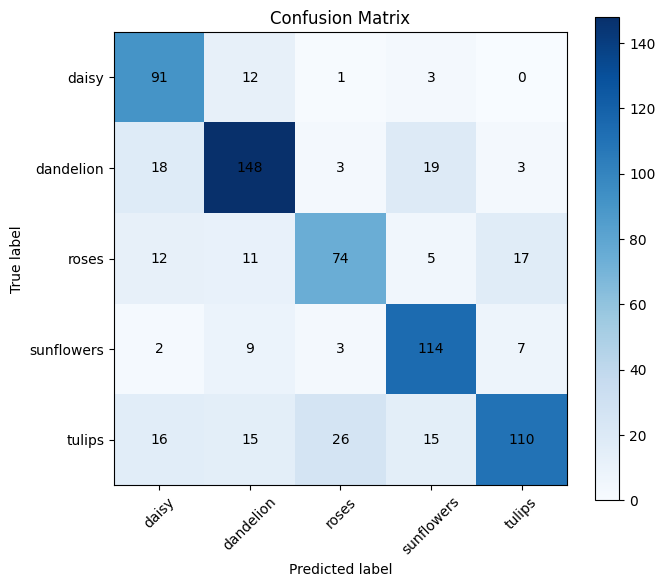

In [8]:
# Confusion Matrix를 그림으로 표시합니다.
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)
plt.colorbar()

# 각 칸에 숫자를 표시합니다.
for row in range(num_classes):
    for col in range(num_classes):
        plt.text(col, row, cm[row, col], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## 8. 클래스별 정확도 보기

클래스별 정확도는 각 꽃 종류를 얼마나 잘 맞혔는지 따로 보는 지표입니다.

전체 정확도가 괜찮아도 특정 클래스 정확도가 낮을 수 있습니다.

In [9]:
class_accuracy_rows = []

for class_index, class_name in enumerate(class_names):
    # 실제 정답이 이 클래스인 이미지들만 고릅니다.
    mask = all_true_labels == class_index
    
    # 해당 클래스 이미지 수입니다.
    total_count = mask.sum()
    
    # 그중 모델이 맞힌 개수입니다.
    correct_count = (all_pred_labels[mask] == class_index).sum()
    
    # 0으로 나누는 상황을 피하기 위해 total_count가 0인지 확인합니다.
    accuracy = correct_count / total_count if total_count > 0 else 0
    
    class_accuracy_rows.append({
        "class": class_name,
        "total": int(total_count),
        "correct": int(correct_count),
        "accuracy": accuracy,
    })

class_accuracy_df = pd.DataFrame(class_accuracy_rows)
class_accuracy_df

,class,total,correct,accuracy
0,daisy,107,91,0.850467
1,dandelion,191,148,0.774869
2,roses,119,74,0.621849
3,sunflowers,135,114,0.844444
4,tulips,182,110,0.604396


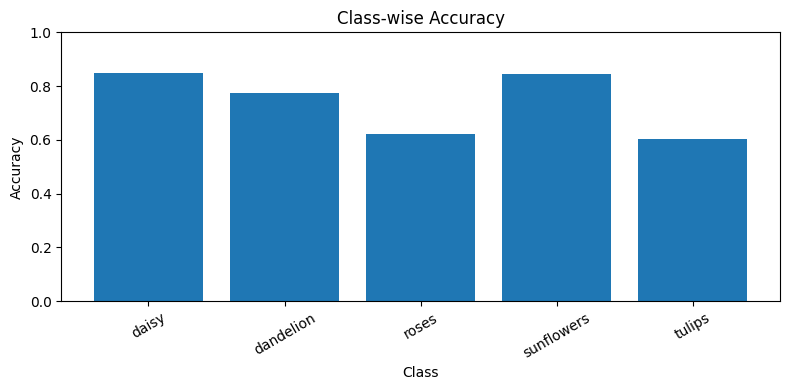

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(class_accuracy_df["class"], class_accuracy_df["accuracy"])
plt.ylim(0, 1)
plt.title("Class-wise Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Classification Report 보기

`classification_report`는 분류 모델을 평가할 때 자주 보는 표입니다.

처음에는 모든 용어를 완벽히 알 필요는 없습니다.

```text
precision = 이 클래스라고 예측한 것 중 진짜 비율
recall    = 실제 이 클래스인 것 중 찾아낸 비율
f1-score  = precision과 recall을 함께 본 점수
support   = 실제 데이터 개수
```

In [11]:
# classification_report()는 클래스별 precision, recall, f1-score를 계산합니다.
report = classification_report(
    all_true_labels,
    all_pred_labels,
    target_names=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

       daisy       0.65      0.85      0.74       107
   dandelion       0.76      0.77      0.77       191
       roses       0.69      0.62      0.65       119
  sunflowers       0.73      0.84      0.78       135
      tulips       0.80      0.60      0.69       182

    accuracy                           0.73       734
   macro avg       0.73      0.74      0.73       734
weighted avg       0.74      0.73      0.73       734



## 10. 오답 이미지 모으기

이제 모델이 틀린 이미지만 따로 모아 봅니다.

오답 이미지를 보는 이유는 단순합니다.

```text
모델이 무엇을 헷갈리는지 직접 보기 위해서
```

In [12]:
# 정답과 예측이 다른 위치만 찾습니다.
wrong_indices = np.where(all_true_labels != all_pred_labels)[0]

print("오답 개수:", len(wrong_indices))

# 확신도가 높은 오답부터 보기 위해 confidence 기준으로 내림차순 정렬합니다.
wrong_indices_sorted = sorted(
    wrong_indices,
    key=lambda index: all_confidences[index],
    reverse=True
)

print("확신도 높은 오답 인덱스 예시:", wrong_indices_sorted[:10])

오답 개수: 197
확신도 높은 오답 인덱스 예시: [np.int64(346), np.int64(456), np.int64(678), np.int64(665), np.int64(675), np.int64(38), np.int64(676), np.int64(11), np.int64(382), np.int64(91)]


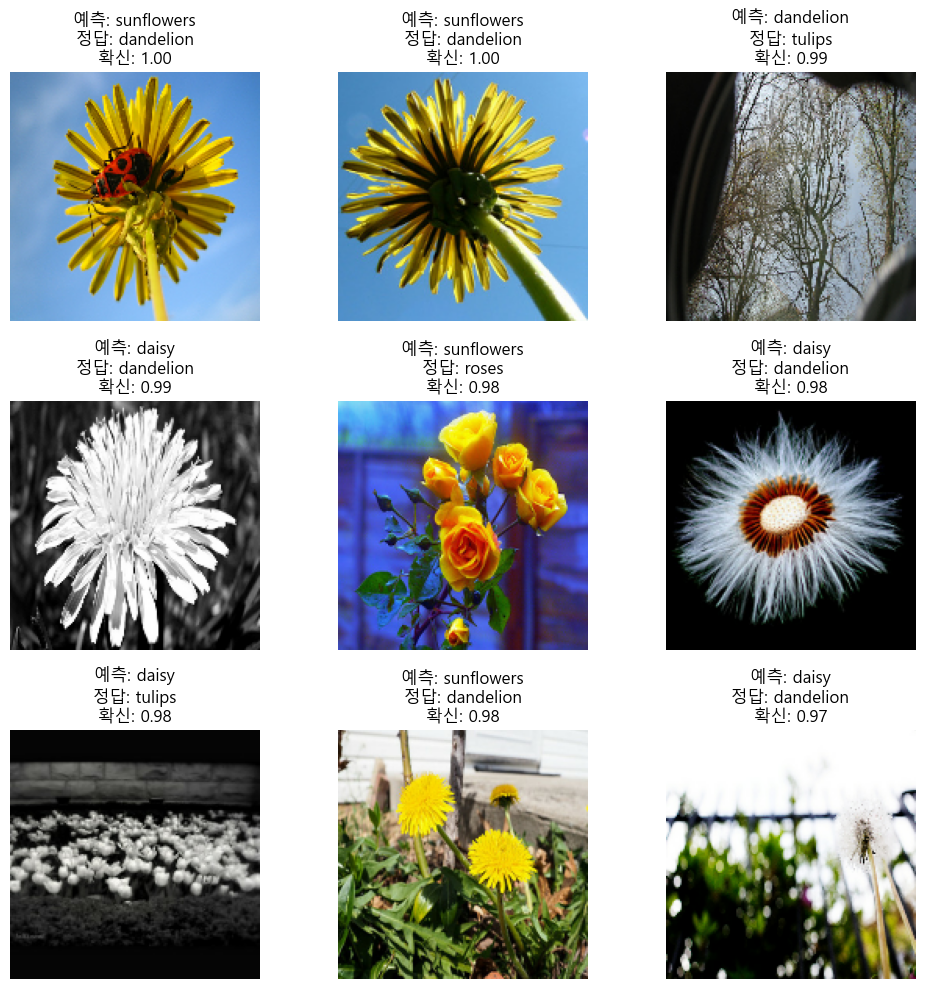

In [13]:
# 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 확신도 높은 오답 이미지를 최대 9장까지 표시합니다.
num_to_show = min(9, len(wrong_indices_sorted))

plt.figure(figsize=(10, 10))

for plot_index in range(num_to_show):
    image_index = wrong_indices_sorted[plot_index]
    
    true_index = all_true_labels[image_index]
    pred_index = all_pred_labels[image_index]
    confidence = all_confidences[image_index]
    
    plt.subplot(3, 3, plot_index + 1)
    plt.imshow(all_images[image_index])
    
    title = (
        f"예측: {class_names[pred_index]}\n"
        f"정답: {class_names[true_index]}\n"
        f"확신: {confidence:.2f}"
    )
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 11. 특정 혼동 관계만 보기

Confusion Matrix에서 특정 두 클래스가 자주 헷갈린다면, 그 경우만 따로 볼 수 있습니다.

예를 들어 장미를 튤립으로 자주 예측한다면 다음처럼 확인할 수 있습니다.

In [14]:
# 여기서는 예시로 roses -> tulips 오답을 찾아봅니다.
# class_names에서 원하는 이름의 위치를 찾습니다.
true_class_name = "roses"
pred_class_name = "tulips"

true_class_index = class_names.index(true_class_name)
pred_class_index = class_names.index(pred_class_name)

specific_wrong_indices = np.where(
    (all_true_labels == true_class_index) &
    (all_pred_labels == pred_class_index)
)[0]

print(f"정답은 {true_class_name}인데 {pred_class_name}로 예측한 개수:", len(specific_wrong_indices))

정답은 roses인데 tulips로 예측한 개수: 17


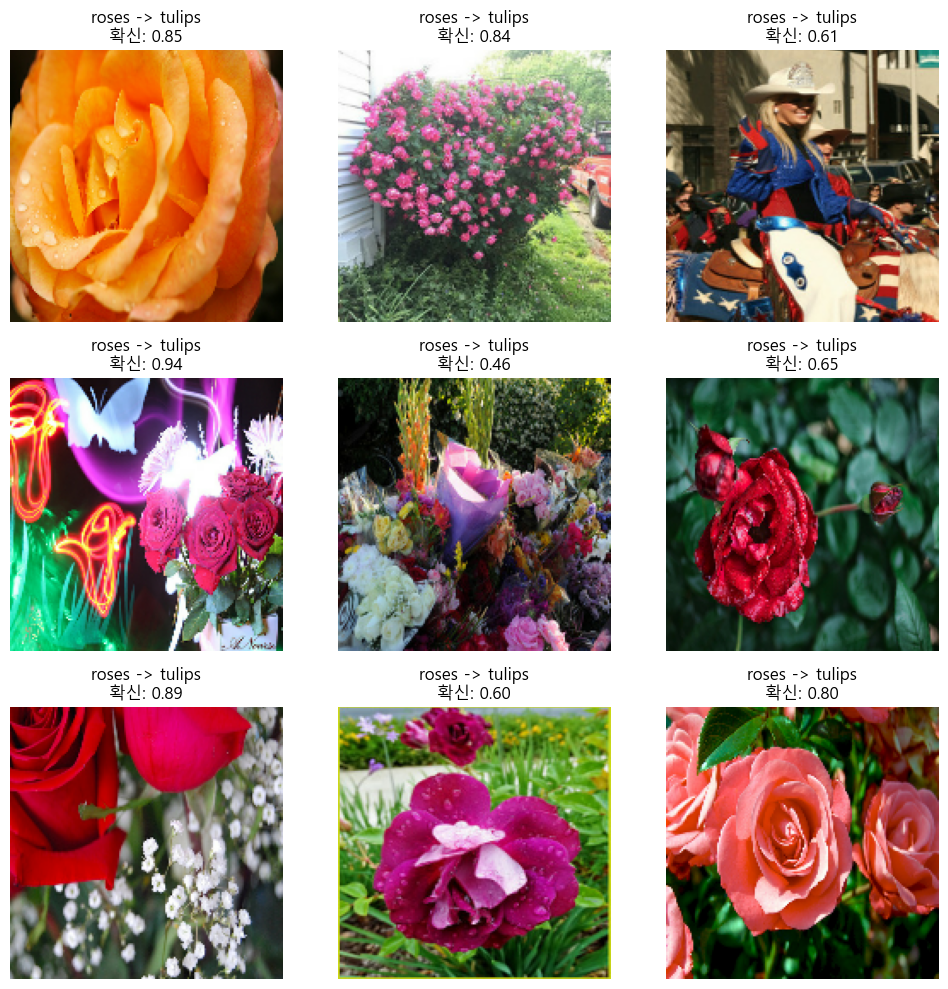

In [15]:
# 특정 혼동 관계에 해당하는 이미지들을 표시합니다.
num_to_show = min(9, len(specific_wrong_indices))

plt.figure(figsize=(10, 10))

for plot_index in range(num_to_show):
    image_index = specific_wrong_indices[plot_index]
    
    plt.subplot(3, 3, plot_index + 1)
    plt.imshow(all_images[image_index])
    plt.title(f"{true_class_name} -> {pred_class_name}\n확신: {all_confidences[image_index]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 12. 분석 문장 만들기

프로젝트에서는 숫자와 그림을 본 뒤, 반드시 해석 문장을 남겨야 합니다.

아래 셀은 분석 문장 작성을 돕기 위한 템플릿입니다.

In [16]:
print("분석 템플릿")
print("- 전체 검증 정확도는 약 {:.2f}%이다.".format(overall_accuracy * 100))
print("- 클래스별 정확도 표에서 가장 낮은 클래스를 확인한다.")
print("- Confusion Matrix에서 대각선 밖 숫자가 큰 조합을 찾는다.")
print("- 확신도 높은 오답 이미지를 보며 모델이 헷갈린 시각적 이유를 적는다.")
print("- 개선 방법으로 데이터 증강, 모델 구조 조정, 전이학습 등을 고려한다.")

분석 템플릿
- 전체 검증 정확도는 약 73.16%이다.
- 클래스별 정확도 표에서 가장 낮은 클래스를 확인한다.
- Confusion Matrix에서 대각선 밖 숫자가 큰 조합을 찾는다.
- 확신도 높은 오답 이미지를 보며 모델이 헷갈린 시각적 이유를 적는다.
- 개선 방법으로 데이터 증강, 모델 구조 조정, 전이학습 등을 고려한다.


## 13. 이번 장 정리

이번 장에서 배운 핵심은 다음과 같습니다.

```text
1. 정확도 하나만으로 모델을 평가하면 부족하다.
2. Confusion Matrix는 정답과 예측의 엇갈림을 보여준다.
3. 클래스별 정확도를 보면 약한 클래스를 찾을 수 있다.
4. 오답 이미지는 모델 개선의 출발점이다.
5. 포트폴리오에서는 분석과 개선 방향까지 설명해야 한다.
```

## 과제

1. Confusion Matrix에서 가장 많이 헷갈린 클래스 조합을 하나 고르세요.
2. 그 오답 이미지들을 보고 왜 헷갈렸을지 세 가지 이유를 적어보세요.
3. 높은 확신도로 틀린 오답과 낮은 확신도로 틀린 오답의 차이를 설명해보세요.
4. 이 모델을 개선한다면 가장 먼저 무엇을 바꿀지 정하고 이유를 적어보세요.